In [2]:
import pandas as pd
import numpy as np
import random
from deap import base, creator, tools, algorithms
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [3]:
# load the processed dataset

df = pd.read_excel('./processed_data/noise_imputed_data.xlsx')
df.set_index('Year', inplace=True)

# define target variable and features
y = df['pollinators_mean_occupancy'].values


X_df = df.drop(columns=[
    'pollinators_mean_occupancy', 
    'pollinating_wild_bees_mean_occupancy', 
    'pollinating_hoverflies_mean_occupancy'
])

X = X_df.values
feature_names = X_df.columns.tolist()
NUM_FEATURES = len(feature_names)

In [4]:
# setup the genetic algorithm using DEAP

# minimize the negative mean cross-validated R^2 score
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

# define chromosomes as a list of binary valies
toolbox = base.Toolbox()

# randomly assign values to each gene
toolbox.register("attr_bool", random.randint, 0, 1)

# create an individual and a population of individuals
def create_individual():
    # let GA optimise the start and end years 
    start_year = 1980
    end_year = 2024

    if start_year >= end_year:
        start_year, end_year = end_year - 1, start_year + 1
    
    # features = [random.randint(0, 1) for _ in range(NUM_FEATURES)]
    features = [1 for _ in range(NUM_FEATURES)] # start with all features included, and let the GA remove them if they are not useful
    return creator.Individual([start_year, end_year] + features)

toolbox.register("individual", create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

In [5]:
# At this point, individuals look like this: 
# [start_year, end_year, feature1_included, feature2_included, ..., featureN_included]


In [6]:
# create evaluation function for finding the best feature subset

def evaluate_feature_subset(individual):
    start_year, end_year = individual[0], individual[1]
    feature_flags = individual[2:]

    # decode the chromosome to get selected feature indices
    selected_indices = [i for i in range(NUM_FEATURES) if feature_flags[i] == 1]

    if len(selected_indices) < 5:
        return (9999.0,) # Penalize if fewer than 5 features are selected
    
    # penalty if the GA tries to drop ALL features (invalid model)
    if len(selected_indices) == 0:
        return (9999.0,) # Return a massive error to kill off this chromosome
    
    # same for invalid years ranges
    if start_year >= end_year:
        return (9999.0,)
    
    # temporal slice
    mask = (df.index >= start_year) & (df.index <= end_year)
    X_masked = X_df.loc[mask, feature_names]
    y_masked = y[mask]

    if X_masked.isnull().any().any():
        # drop columns with missing values in the masked dataset
        cols_with_na = X_masked.columns[X_masked.isnull().any()]
        X_masked = X_masked.drop(columns=cols_with_na)
        selected_indices = [i for i in selected_indices if feature_names[i] not in cols_with_na]

    # Create SVR model pipeline with feature scaling
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
    ])
    
    # 5 fold cross validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # get negative mean squared error scores and convert to RMSE
    try:
        scores = cross_val_score(model, X_masked, y_masked, cv=cv, scoring='neg_mean_squared_error')
        rmse = np.sqrt(-scores.mean())
    except:
        return (9999.0,)
    
    # add a small penalty for every feature used.
    penalty_weight = 0.01

    num_years_captured = end_year - start_year
    
    # Fitness = RMSE - (reward for long timelines) + (penalty for too many features)
    fitness_score = rmse - (0.15 * num_years_captured)# + (penalty_weight * len(selected_indices))

    
    return (fitness_score,)

# Register the evaluation function
toolbox.register("evaluate", evaluate_feature_subset)

In [7]:
# need a custom mutation function to ensure valid year ranges
def custom_mutate(individual, indpb):
    # 30% chance to mutate the years
    if random.random() < indpb:
        individual[0] = random.randint(1980, 2023)
    if random.random() <indpb:
        individual[1] = random.randint(1980, 2024)
    # mutate features normally
    for i in range(2, len(individual)):
        if random.random() < indpb:
            individual[i] = type(individual[i])(not individual[i])
    return individual,

In [8]:
# uniform crossover 50% chance of swapping each gene
toolbox.register("mate", tools.cxUniform, indpb=0.5)

toolbox.register("mutate", custom_mutate, indpb=0.1)

# picks the best randomly chosen individuals
toolbox.register("select", tools.selTournament, tournsize=3)

In [9]:

print("Initializing Genetic Algorithm")

# create initial population
pop = toolbox.population(n=50)

# HOF keeps track of the absolute best individual across all generations
hof = tools.HallOfFame(1)

# # stats to print to console during the run
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("min", np.min)

pop, log = algorithms.eaSimple(pop, 
                                toolbox, 
                                cxpb=0.5, 
                                mutpb=0.2, 
                                ngen=20,
                               stats=stats, 
                                halloffame=hof, 
                                verbose=True)

# results
best_ind = hof[0]
print("\n" + "="*40)
print("OPTIMIZATION COMPLETE")
print("="*40)
print(f"Best Fitness Score (RMSE + Penalty): {best_ind.fitness.values[0]:.4f}")

print("\nOptimized Feature Subset:")
selected_features = []
for i in range(NUM_FEATURES):
    if best_ind[i] == 1:
        selected_features.append(feature_names[i])
        print(f"  [X] {feature_names[i]}")
    else:
        print(f"  [ ] {feature_names[i]}")
        
print(f"\nTotal Features Kept: {len(selected_features)} out of {NUM_FEATURES}")
print(f"Dimensionality Reduction: {100 - (len(selected_features)/NUM_FEATURES)*100:.1f}%")
    

Initializing Genetic Algorithm
gen	nevals	avg    	min    
0  	50    	5.37382	5.37382
1  	27    	5.09513	-0.0168075
2  	28    	204.477	-0.0168075
3  	34    	3.83042	-0.252561 
4  	23    	401.982	-0.252561 
5  	25    	0.410794	-0.252561 
6  	32    	200.227 	-0.252561 
7  	29    	200.098 	-0.252561 
8  	38    	799.872 	-0.252561 
9  	22    	-0.136511	-0.252561 
10 	34    	-0.128218	-0.252561 
11 	37    	-0.0952453	-0.252561 
12 	23    	199.732   	-0.252561 
13 	28    	-0.117047 	-0.252561 
14 	41    	199.986   	-0.252561 
15 	33    	-0.103185 	-0.252561 
16 	31    	399.718   	-0.252561 
17 	25    	-0.113881 	-0.252561 
18 	36    	399.763   	-0.252561 
19 	28    	199.896   	-0.252561 
20 	28    	399.879   	-0.252561 

OPTIMIZATION COMPLETE
Best Fitness Score (RMSE + Penalty): -0.2526

Optimized Feature Subset:
  [ ] butterfly_connectivity_composite_unsmoothed_index
  [ ] birds_connectivity_composite_unsmoothed_index
  [ ] mean_connectivity_woodland
  [X] mean_connectivity_grassland
  [ ] b

<Axes: >

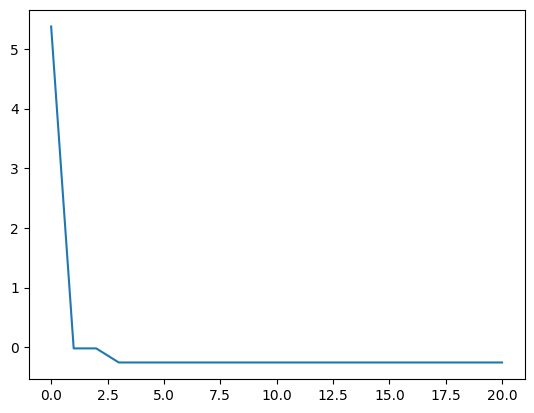

In [10]:

min_log = log.select("min")
import seaborn as sns

sns.lineplot(x=range(len(min_log)), y=min_log)

In [11]:
best_ind



[2015, 2024, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]